# Notebook 3: Bank Clustering

## Objective
Group European banks into clusters based on their financial profile using PCA for dimensionality reduction and K-Means for clustering.
This allows us to identify structurally similar banks and classify institutions by risk profile.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load cleaned dataset
df = pd.read_csv("banking_indicators_clean.csv")
df['Period'] = pd.to_datetime(df['Period'])

# Only lates period
df_latest = df[df['Period']==df['Period'].max()].copy()
df_latest = df_latest[df_latest['CET1_ratio']<50].reset_index(drop=True)

print(df_latest.shape)
print(df_latest[['Name', 'Country', 'CET1_ratio', 'total_assets']].head())

(116, 8)
                                 Name Country  CET1_ratio  total_assets
0      DekaBank Deutsche Girozentrale      DE   21.067832  96079.978435
1                         CEC BANK SA      RO   23.968878  19594.394888
2  Akciju sabiedrība "Citadele banka"      LV   20.275593   5032.170571
3                     Alpha Bank S.A.      GR   16.078933  72269.488872
4               AIKGROUP (CY) LIMITED      SI   16.730552   9795.484573


In [2]:
# Select features for clustering
features = ['CET1_ratio', 'total_assets']
X = df_latest[features].dropna()

# Keep track of included banks
df_cluster = df_latest.loc[X.index].copy()

# Standadise features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features shape:", X_scaled.shape)
print("Mean after scaling:", X_scaled.mean(axis=0).round(4))
print("Std after scaling:", X_scaled.std(axis=0).round(4))

Features shape: (105, 2)
Mean after scaling: [0. 0.]
Std after scaling: [1. 1.]


## 2. Choosing the Optimal Number of Clusters

The elbow method shows that inertia decreases sharply up to k=3 and then flattens out. 
The silhouette score confirms k=3 as optimal, with a score of ~0.65 indicating well-separated and compact clusters.
We therefore proceed with k=3 for the final clustering.

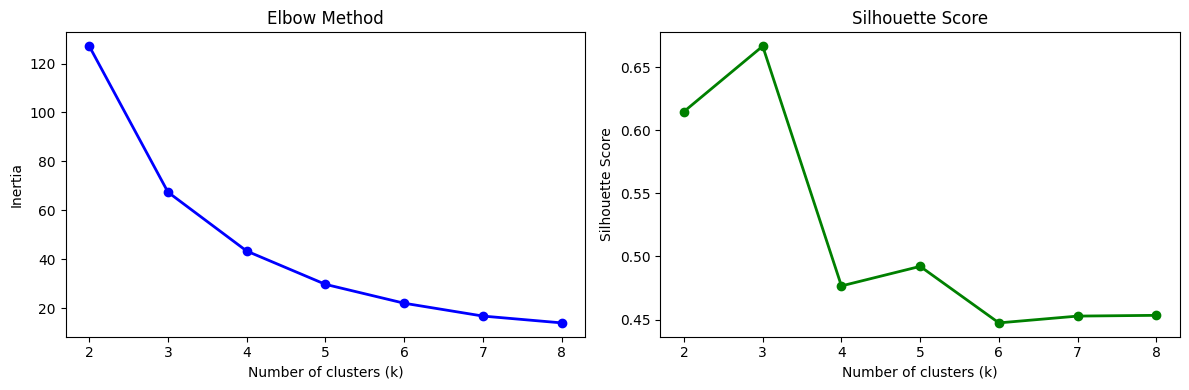

Optimal k by silhouette: 3


In [3]:
# Elbow method (to find the optimal number of clusters)
# Inertia measures how compact the clusters are (lower is better)
# Silhouette score measures how well separated the clusters are (higher is better)

inertias=[]
silhouettes=[]
k_range = range(2,9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

# Plot both metrics side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Elbow curve - look for the 'elbow' where inertia stops decreasing sharply
axes[0].plot(k_range, inertias, 'bo-', linewidth=2)
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')

# Right: Silhouette score - pick the k with the highest score
axes[1].plot(k_range, silhouettes, 'go-', linewidth=2)
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('plot_05_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

# Print optimal k
print("Optimal k by silhouette:", k_range[silhouettes.index(max(silhouettes))])


In [4]:
# Fit final K-Means model with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(X_scaled)

# Apply PCA for 2D visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_cluster['pca1'] = X_pca[:, 0]
df_cluster['pca2'] = X_pca[:, 1]

print("Variance explained by PCA:", pca.explained_variance_ratio_.sum().round(3))
print(df_cluster['cluster'].value_counts().sort_index())

Variance explained by PCA: 1.0
cluster
0    92
1     8
2     5
Name: count, dtype: int64


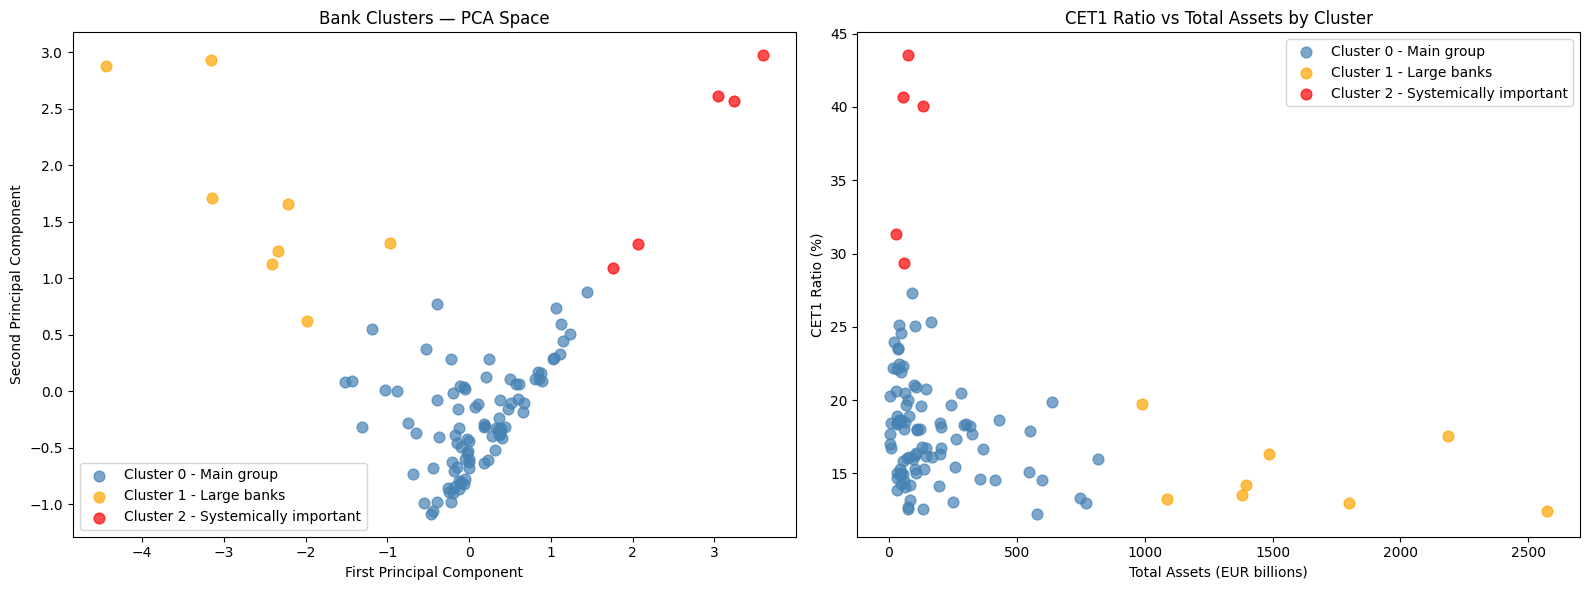

In [5]:
# Define cluster colors and labels
colors = {0: 'steelblue', 1: 'orange', 2: 'red'}
labels = {0: 'Cluster 0 - Main group', 1: 'Cluster 1 - Large banks', 2: 'Cluster 2 - Systemically important'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: PCA scatter plot
for cluster in sorted(df_cluster['cluster'].unique()):
    mask = df_cluster['cluster'] == cluster
    axes[0].scatter(df_cluster.loc[mask, 'pca1'],
                    df_cluster.loc[mask, 'pca2'],
                    c=colors[cluster],
                    label=labels[cluster],
                    alpha=0.7,
                    s=60)
axes[0].set_title('Bank Clusters — PCA Space')
axes[0].set_xlabel('First Principal Component')
axes[0].set_ylabel('Second Principal Component')
axes[0].legend()

# Right: CET1 ratio vs total assets colored by cluster
for cluster in sorted(df_cluster['cluster'].unique()):
    mask = df_cluster['cluster'] == cluster
    axes[1].scatter(df_cluster.loc[mask, 'total_assets'] / 1000,
                    df_cluster.loc[mask, 'CET1_ratio'],
                    c=colors[cluster],
                    label=labels[cluster],
                    alpha=0.7,
                    s=60)
axes[1].set_title('CET1 Ratio vs Total Assets by Cluster')
axes[1].set_xlabel('Total Assets (EUR billions)')
axes[1].set_ylabel('CET1 Ratio (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('plot_06_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Cluster interpretation

The K-Means algorithm with k=3 identifies three structurally distinct groups:

**Cluster 0 — Standard institutions (n=92)**
The main group of small and medium-sized European banks. Total assets below EUR 500bn, CET1 ratios between 12% and 25%. Broadly representative of the European banking landscape.

**Cluster 1 — Large systemic banks (n=8)**
Large institutions with total assets above EUR 500bn. These banks tend to operate with lower CET1 ratios, likely reflecting greater diversification and more sophisticated internal risk models (IRB approach).

**Cluster 2 — High-capital institutions (n=5)**
Small institutions with unusually high CET1 ratios (above 29%). These may reflect specialised business models with very low risk-weighted assets relative to capital, or conservative capital management strategies.

In [6]:
# Identify banks in each cluster
for c in [1, 2]:
    print(f"\n--Cluster {c} ---")
    print(df_cluster[df_cluster['cluster'] == c][['Name', 'Country', 'CET1_ratio', 'total_assets']].sort_values('total_assets', ascending = False).to_string(index=False))


--Cluster 1 ---
                                    Name Country  CET1_ratio  total_assets
                             BNP Paribas      FR   12.458721  2.573934e+06
                  Groupe Crédit Agricole      FR   17.581654  2.187749e+06
                   Banco Santander, S.A.      ES   12.984878  1.797910e+06
                             Groupe BPCE      FR   16.312493  1.486359e+06
        DEUTSCHE BANK AKTIENGESELLSCHAFT      DE   14.237339  1.395880e+06
                   Société générale S.A.      FR   13.539140  1.380480e+06
                          ING Groep N.V.      NL   13.261921  1.086760e+06
Confédération Nationale du Crédit Mutuel      FR   19.760463  9.882176e+05

--Cluster 2 ---
                                                  Name Country  CET1_ratio  total_assets
                                         BNG Bank N.V.      NL   40.052931 132223.993054
                                             SFIL S.A.      FR   43.523888  73305.804971
                      In

### Cluster composition

**Cluster 1** is dominated by French banks (5 out of 8), reflecting the high concentration of the French banking sector.
All institutions have total assets above EUR 900bn and are classified as Global or Other Systemically Important Institutions (G-SII/O-SII). Their relatively lower CET1 ratios reflect the use of advanced Internal Ratings-Based (IRB) models, which typically produce lower Risk-Weighted Assets than the standardised approach.

**Cluster 2** consists of specialised institutions with non-standard business models: public development banks (BNG, SFIL), a custody bank (State Street), a conservative retail bank (Argenta) and a neobank (Revolut).
Their high CET1 ratios are explained by very low Risk-Weighted Assets relative to total assets, not by exceptionally high capital levels.

## 4. Cluster Summary Statistics

In [7]:
# Summary statistics by cluster
summary = df_cluster.groupby('cluster').agg(
    n_banks=('Name', 'count'),
    avg_CET1_ratio=('CET1_ratio', 'mean'),
    median_CET1_ratio=('CET1_ratio', 'median'),
    min_CET1_ratio=('CET1_ratio', 'min'),
    max_CET1_ratio=('CET1_ratio', 'max'),
    avg_total_assets=('total_assets', 'mean')
).round(2)

# Convert total assets to billions for readability
summary['avg_total_assets_bn'] = (summary['avg_total_assets'] / 1000).round(1)
summary = summary.drop(columns=['avg_total_assets'])

# Rename index for clarity
summary.index = ['Cluster 0 (Standard)', 'Cluster 1 (Large systemic)', 'Cluster 2 (High capital)']

print(summary.to_string())

                            n_banks  avg_CET1_ratio  median_CET1_ratio  min_CET1_ratio  max_CET1_ratio  avg_total_assets_bn
Cluster 0 (Standard)             92           17.74              17.67           12.25           27.30                162.2
Cluster 1 (Large systemic)        8           15.02              13.89           12.46           19.76               1612.2
Cluster 2 (High capital)          5           36.98              40.05           29.35           43.52                 69.6


## 5. Conclusions

The clustering analysis identifies three structurally distinct groups within the European banking sector:

- **Standard institutions (92 banks):** The core of the European banking system, with average CET1 of 17.7% and moderate size. Well capitalised and broadly homogeneous in their risk profile.

- **Large systemic banks (8 banks):** The largest institutions in the sample, averaging EUR 1.6 trillion in assets. They operate with lower CET1 ratios (~15%), reflecting advanced risk models and implicit too-big-to-fail advantages. These banks warrant closer macroprudential monitoring given their systemic importance.

- **High-capital institutions (5 banks):** Specialised institutions with non-standard business models and very low risk-weighted assets. 
  Their high CET1 ratios do not reflect excessive capitalisation but rather the nature of their activities.

These clusters will inform the Early Warning System in Notebook 4, where we build a model to predict capital deterioration at the bank level.